### **Task 2: Personal Loan Purchase Prediction**


**Objective:** The goal of this project is to predict which customers are likely to accept a personal loan offer from the bank. By analyzing factors like income, education, and family size, we can help the bank target the right audience for their next campaign.


In [1]:
# Importing basic libraries for analysis and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading and Inspection



In [2]:



# Loading the dataset 

data = pd.read_excel("Bank_Personal_Loan_Modelling.xlsx", sheet_name='Data')

# Checking first 5 rows
print("Data Preview:")
print(data.head())

# Checking the size of the data
print("\nDataset Shape:")
print(data.shape)

# Checking column types and non-null counts
print("\nGeneral Info:")
data.info()

Data Preview:
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  

Dataset Shape:
(5000, 14)

General Info:
<class 'pandas.DataFrame'>
RangeIndex

# 2. Data Cleaning



In [3]:
# Checking null values
print("Missing Values per Column:")
print(data.isnull().sum())


data = data.drop(['ID', 'ZIP Code'], axis=1)

# Removing duplicate rows
data = data.drop_duplicates()

print("\nData cleaned and unnecessary columns removed.")


Missing Values per Column:
ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

Data cleaned and unnecessary columns removed.


## 3. Exploratory Data Analysis (EDA)



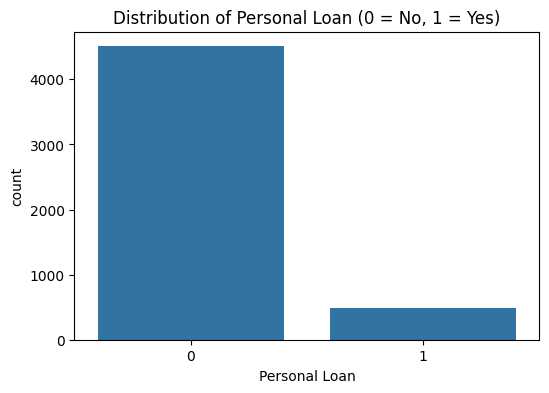

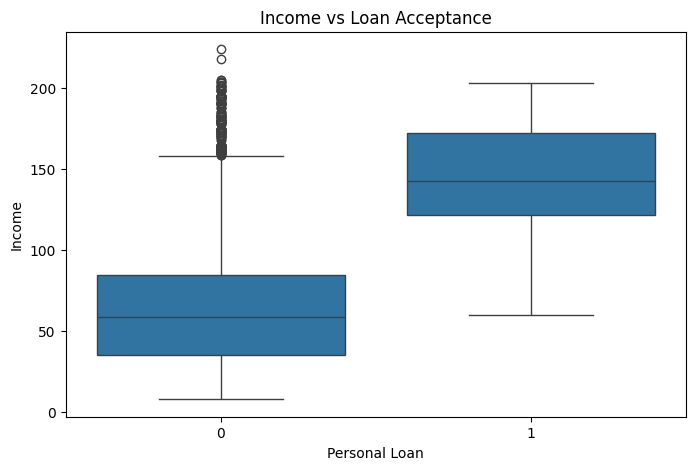

In [4]:
# Plotting the target 'Personal Loan'
plt.figure(figsize=(6, 4))
sns.countplot(x='Personal Loan', data=data)
plt.title('Distribution of Personal Loan (0 = No, 1 = Yes)')
plt.show()

#  relationship between Income and Loan
plt.figure(figsize=(8, 5))
sns.boxplot(x='Personal Loan', y='Income', data=data)
plt.title('Income vs Loan Acceptance')
plt.show()


## 4. Model Preparation



In [5]:
# Defining features (X) and target (y)
X = data.drop('Personal Loan', axis=1)
y = data['Personal Loan']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


## 5. Model Training and Evaluation


Model Accuracy Score: 0.9509018036072144


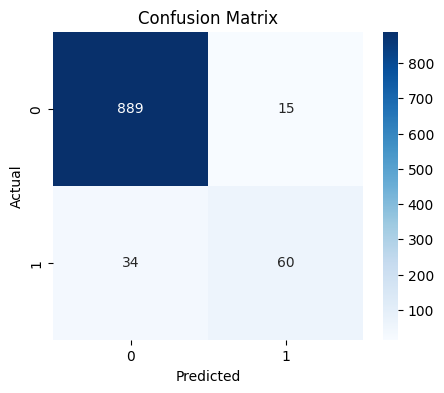

In [6]:
# training the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Checking accuracy
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy Score:", acc)

# Creating a Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6. Conclusion and Learning Note
**Income Factor:**   I noticed that customers with a higher annual income are much more likely to accept a personal loan offer compared to others.

**Model Success:**   My Logistic Regression model performed quite well and gave a high accuracy score, 
which shows it is a good tool for this kind of prediction.

**Data Cleaning:**   I learned that removing useless ID columns and scaling the values helps the model run much more efficiently and faster.

**Real-world Insight:**   Overall, this project was a great way for me to understand how machine learning is actually used in the banking sector.